In [32]:
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
MAIN_FOLDER = "/home/arman/it/AI_work/analyze_data/turkiye_students"

In [34]:
data = pd.read_csv(f"{MAIN_FOLDER}/dataset/turkiye_students.csv")
print(data.shape)
data.head()

(5820, 33)


,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,1,2,1,0,4,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,1,2,1,2,4,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
4,1,2,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


в данной чистке данных я буду пытаться очистить датасет от ложных и некоректных ответов

google translator

instr: Идентификатор преподавателя; значения взяты из {1,2,3} \
class: Код курса (дескриптор); значения взяты из {1-13} \
repeat: Количество раз, когда студент проходит этот курс; значения взяты из {0,1,2,3,…} \
attendance: Код уровня посещаемости; значения из {0, 1, 2, 3, 4} \
difficulty: Уровень сложности курса, по мнению студента; значения взяты из {1,2,3,4,5} \
Q1: Содержание семестрового курса, методика преподавания и система оценки были предоставлены в начале. \
Q2: Цели и задачи курса были четко сформулированы в начале периода. \
Q3: Курс соответствовал количеству зачетных единиц, присвоенных ему. \
Q4: Курс преподавался в соответствии с программой, объявленной в первый день занятий. \
Q5: Обсуждения на занятиях, домашние задания, практические работы и исследования были удовлетворительными.

Q6: Учебник и другие учебные материалы были достаточными и актуальными. \
Q7: Курс предусматривал полевые работы, применение полученных знаний на практике, лабораторные занятия, дискуссии и другие виды исследований. \
Q8: Тесты, задания, проекты и экзамены способствовали обучению. \
Q9: Мне очень понравились занятия, и я с удовольствием принимал активное участие в лекциях. \
Q10: Мои первоначальные ожидания от курса оправдались к концу учебного года. \
Q11: Курс был актуальным и полезным для моего профессионального развития. \
Q12: Курс помог мне взглянуть на жизнь и мир с новой точки зрения. \
Q13: Знания преподавателя были актуальными и современными. \
Q14: Преподаватель приходил на занятия подготовленным. \
Q15: Преподаватель преподавал в соответствии с объявленным планом занятий. \
Q16: Преподаватель был предан курсу и его объяснения были понятны. \
Q17: Преподаватель приходил на занятия вовремя.

Q18: Преподаватель излагает материал плавно и доступно. \
Q19: Преподаватель эффективно использует учебное время. \
Q20: Преподаватель объясняет курс и стремится помочь студентам. \
Q21: Преподаватель демонстрирует позитивный подход к студентам. \
Q22: Преподаватель открыто и уважительно относится к мнению студентов о курсе. \
Q23: Преподаватель поощряет участие в курсе. \
Q24: Преподаватель дает соответствующие домашние задания/проекты и помогает/направляет студентов. \
Q25: Преподаватель отвечает на вопросы о курсе как во время занятий, так и вне их. \
Q26: Система оценки преподавателя (вопросы на промежуточном и итоговом экзаменах, проекты, задания и т. д.) эффективно измеряет достижение целей курса. \
Q27: Преподаватель предоставляет решения к экзаменам и обсуждает их со студентами. \
Q28: Преподаватель относится ко всем студентам справедливо и объективно. \
Вопросы Q1-Q28 относятся к типу Ликерта, то есть значения взяты из множества {1,2,3,4,5}.

## посещаемость студентов

{0: '32.68%', 1: '17.66%', 2: '13.61%', 3: '21.51%', 4: '14.54%'}


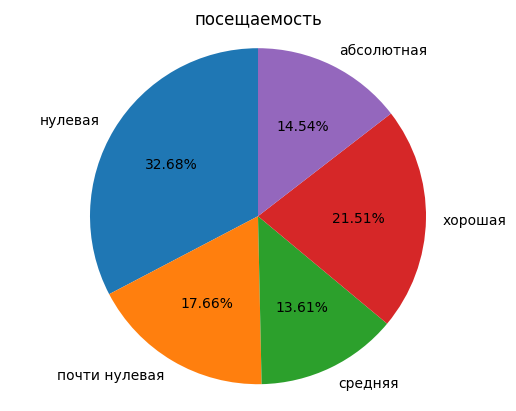

In [35]:
attendance_metric = {}
for attendance_mark in range(5):    
    attendance_metric[attendance_mark] = (data[(data["attendance"]==attendance_mark)].shape[0]) / (data.shape[0])

pprint({k: f"{v*100:1.2f}%" for k, v in attendance_metric.items()})

labels = [
    "нулевая",
    "почти нулевая",
    "средняя",
    "хорошая",
    "абсолютная",
]
sizes = list(attendance_metric.values())

plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)
plt.axis('equal')
plt.title("посещаемость")
plt.show()

# Теперь переходим на очищенные данные

In [36]:
data = pd.read_csv(f"{MAIN_FOLDER}/dataset/cleaned_turkiye_students.csv")
print(data.shape)
data.head()

(2094, 34)


,Unnamed: 0,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,8,1,2,1,1,3,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
1,14,1,2,1,2,3,1,1,1,1,...,2,3,3,3,2,2,1,1,1,1
2,15,1,2,1,3,4,5,5,4,4,...,5,4,4,5,5,4,4,4,5,4
3,22,1,2,1,3,3,3,3,3,3,...,3,2,1,1,1,3,2,2,2,2
4,23,1,2,1,2,4,5,3,3,3,...,2,2,4,4,5,5,4,4,5,5


## средние оценки по каждому вопросу

{'Q1': '2.67', 'Q2': '2.99', 'Q3': '3.23', 'Q4': '3.00', 'Q5': '3.06', 'Q6': '3.06', 'Q7': '2.96', 'Q8': '2.91', 'Q9': '3.18', 'Q10': '3.01', 'Q11': '3.24', 'Q12': '2.89', 'Q13': '3.37', 'Q14': '3.47', 'Q15': '3.46', 'Q16': '3.18', 'Q17': '3.72', 'Q18': '3.32', 'Q19': '3.41', 'Q20': '3.46', 'Q21': '3.51', 'Q22': '3.53', 'Q23': '3.27', 'Q24': '3.19', 'Q25': '3.52', 'Q26': '3.31', 'Q27': '3.15', 'Q28': '3.52'}


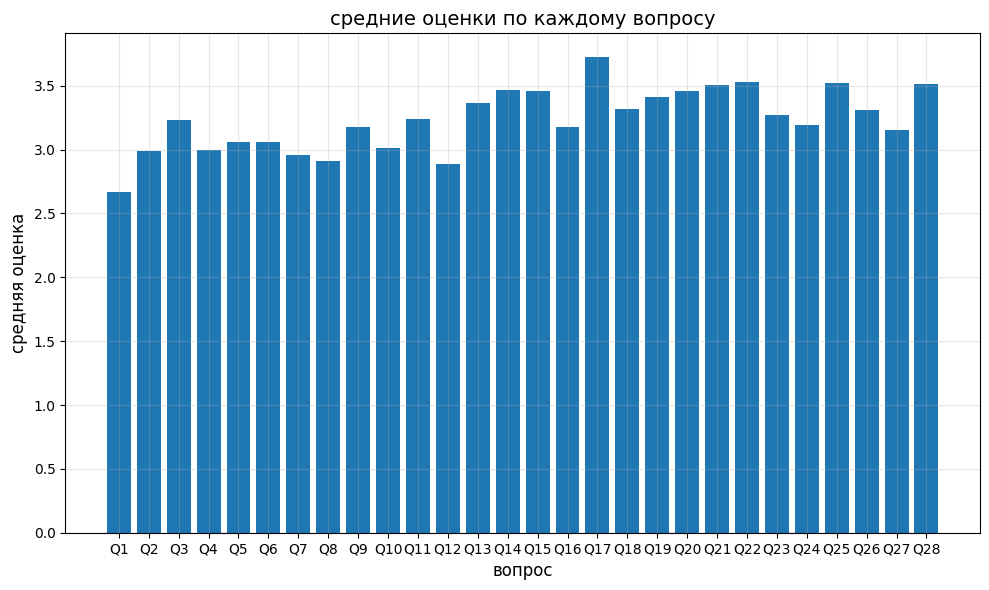

In [37]:
middle_marks_metric = {}
for q in [f"Q{i}" for i in range(1,28+1)]:
    middle_marks_metric[q] = data[q].mean()

print({k: f"{v:1.2f}" for k, v in middle_marks_metric.items()})

middle_marks_metric_x = [int(k.replace("Q", "")) for k in middle_marks_metric.keys()]
middle_marks_metric_labels = list(middle_marks_metric.keys())
middle_marks_metric_y = list(middle_marks_metric.values())

plt.figure(figsize=(10, 6))
plt.bar(middle_marks_metric_labels, middle_marks_metric_y)
plt.xlabel('вопрос', fontsize=12)
plt.ylabel('средняя оценка', fontsize=12)
plt.title("средние оценки по каждому вопросу", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
# средняя оценка из всего
sum(middle_marks_metric_y) / len(middle_marks_metric_y)

np.float64(3.235042297721381)

# матрица корреляций всех вопросов

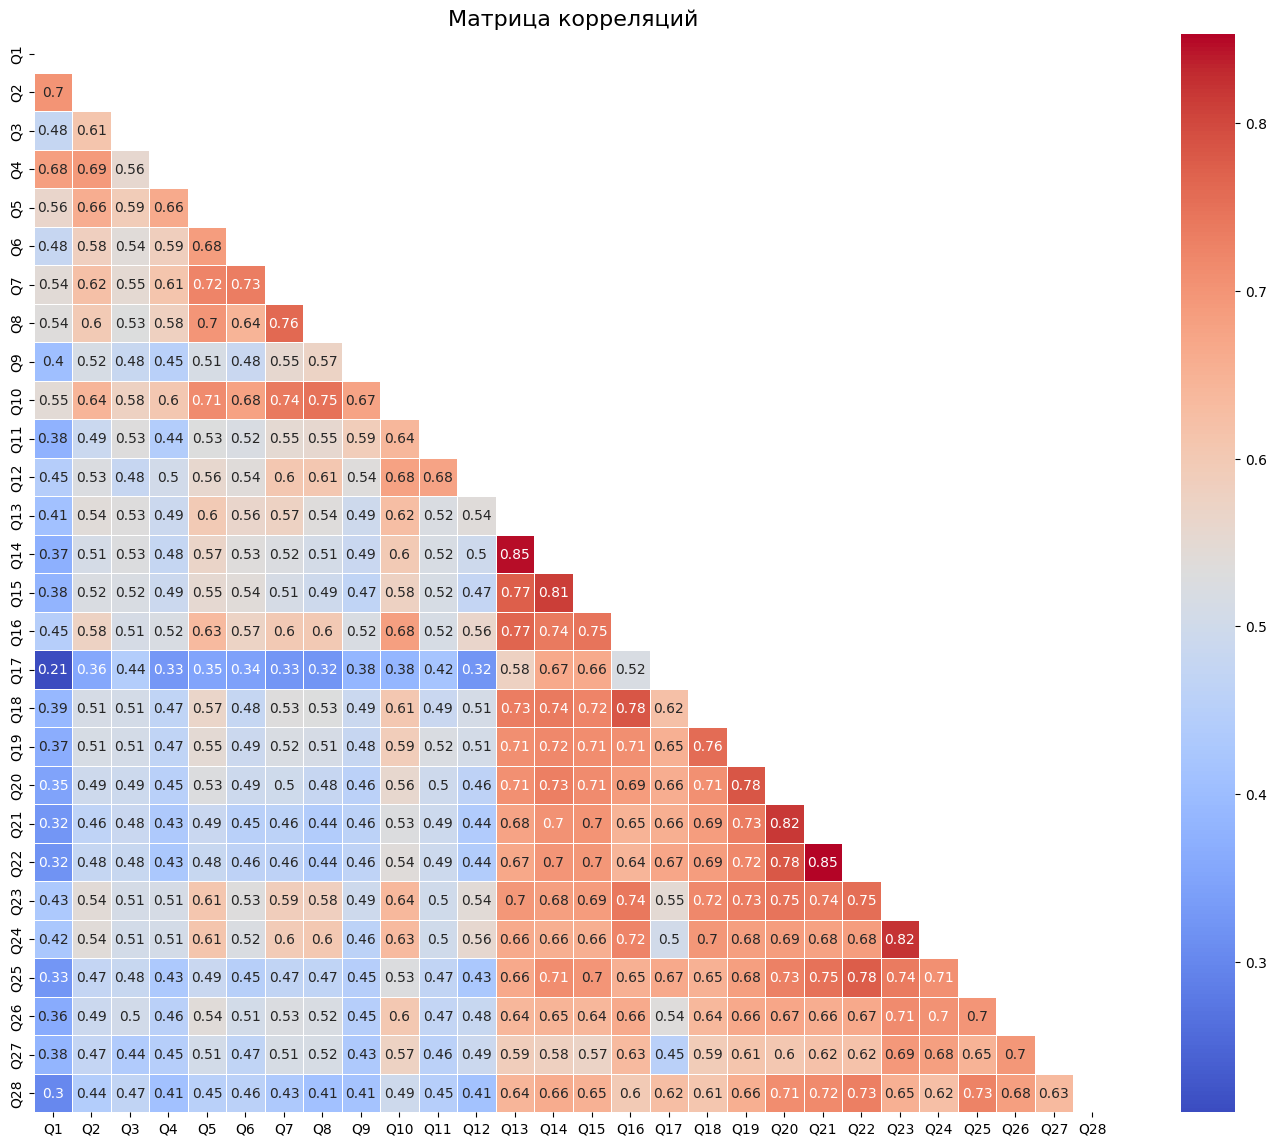

In [39]:
columns_to_drop = [col for col in data.columns if not col.replace("Q", "").isdigit()]
clear_df = data.drop(columns=columns_to_drop)
corr_matrix = clear_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляций', fontsize=16)
plt.show()

# сильные и слабые стороны преподавателей

In [40]:
# my_data = {instr_id: {f"Q{i}": [] for i in range(13,28+1)} for instr_id in [1,2,3]}
my_data = {f"Q{i}": {instr_id: [] for instr_id in [1,2,3]} for i in range(13,28+1)}
for q in [f"Q{i}" for i in range(13,28+1)]: # речь только о вопросах про преподавателя
    for instr_id in [1,2,3]:
        my_data[q][instr_id] = data[data["instr"] == instr_id][q].mean()

In [41]:
my_data

{'Q13': {1: np.float64(3.50381679389313),
  2: np.float64(3.5902255639097747),
  3: np.float64(3.246153846153846)},
 'Q14': {1: np.float64(3.6068702290076335),
  2: np.float64(3.6184210526315788),
  3: np.float64(3.3815384615384616)},
 'Q15': {1: np.float64(3.5610687022900764),
  2: np.float64(3.6165413533834587),
  3: np.float64(3.3723076923076922)},
 'Q16': {1: np.float64(3.3587786259541983),
  2: np.float64(3.4718045112781954),
  3: np.float64(3.02)},
 'Q17': {1: np.float64(3.801526717557252),
  2: np.float64(3.830827067669173),
  3: np.float64(3.6653846153846152)},
 'Q18': {1: np.float64(3.5763358778625953),
  2: np.float64(3.7330827067669174),
  3: np.float64(3.1)},
 'Q19': {1: np.float64(3.5381679389312977),
  2: np.float64(3.669172932330827),
  3: np.float64(3.2830769230769232)},
 'Q20': {1: np.float64(3.446564885496183),
  2: np.float64(3.6503759398496243),
  3: np.float64(3.3784615384615386)},
 'Q21': {1: np.float64(3.3893129770992365),
  2: np.float64(3.7274436090225564),
  3

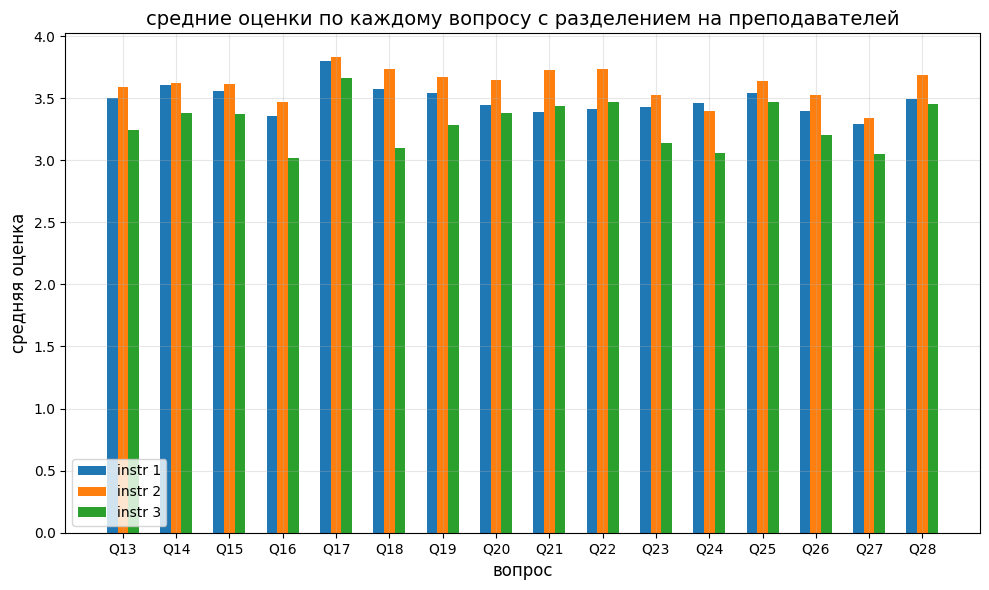

In [42]:
cat_par = [f"Q{i}" for i in range(13,28+1)]
instr_data = [[] for _instr_id in range(3+1)]
for q in [f"Q{i}" for i in range(13,28+1)]:
    for instr_id in [1,2,3]:
        instr_data[instr_id].append(my_data[q][instr_id])
width = 0.2
x = np.arange(len(cat_par))
# fig, ax = plt.subplots()
plt.figure(figsize=(10, 6))
plt.bar(x - width, instr_data[1], width, label='instr 1')
plt.bar(x, instr_data[2], width, label='instr 2')
plt.bar(x + width, instr_data[3], width, label='instr 3')
plt.xticks(x, cat_par)
plt.xlabel('вопрос', fontsize=12)
plt.ylabel('средняя оценка', fontsize=12)
plt.title("средние оценки по каждому вопросу с разделением на преподавателей", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
plt.legend(loc="lower left")

